# FGW distance and MACE single-point energy landscapes

This notebook visualizes the registry-dependent relative FGW distance ($\Delta d_{\mathrm{FGW}}$) and MACE single-point energy ($\Delta E_{\mathrm{SP}}$) over the fractional interfacial shifts $\Delta a$ and $\Delta b$ for 

- KI/NaCl
- GaP/GaAs
- GaN/$\mathrm{Al_{2}O_3}$


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = [r"KI/NaCl", r"GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
paths = [f"mace_results/{system}.csv" for system in systems]
# Column names
energy_col = "mace_single_point_energy"
fgw_col = "fgw_distance_megn_050"
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
fig_layout = dict(
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05,
    wspace=0.25,
    hspace=0.1,
)
panel_label_size = 14
fig_width = 7.2
fig_height = 4.5
cmap = "Blues_r"
levels = 50


## Data preparation


In [7]:
data_store = []
energies = []
fgw_ds = []

for system, title, path in zip(systems, titles, paths):
    df = pd.read_csv(path).copy()
    # Check the input data
    value_cols = [energy_col, fgw_col]
    if df[value_cols].isna().any().any():
        bad_rows = df[df[value_cols].isna().any(axis=1)]
        raise ValueError(
            f"{system}: missing energy or FGW distance found:\n{bad_rows}"
        )
    # Convert absolute single-point energy and FGW distance to relative energy and distance
    df["relative_energy"] = df[energy_col] - df[energy_col].min()
    df["relative_distance"] = df[fgw_col] - df[fgw_col].min()
    energy_grid = df.pivot(
        index="shift_b",
        columns="shift_a",
        values="relative_energy",
    ).sort_index(axis=0).sort_index(axis=1)
    fgw_d_grid = df.pivot(
        index="shift_b",
        columns="shift_a",
        values="relative_distance",
    ).sort_index(axis=0).sort_index(axis=1)
    x = energy_grid.columns.to_numpy(dtype=float)
    y = energy_grid.index.to_numpy(dtype=float)
    z_energy = energy_grid.values
    z_fgw_d = fgw_d_grid.values
    data_store.append((x, y, z_energy, z_fgw_d))
    energies.append(z_energy)
    fgw_ds.append(z_fgw_d)

# Use global colour scales across all systems
energy_min = min(e.min() for e in energies)
energy_max = max(e.max() for e in energies)
fgw_d_min = min(f.min() for f in fgw_ds)
fgw_d_max = max(f.max() for f in fgw_ds)


## Landscape visualization


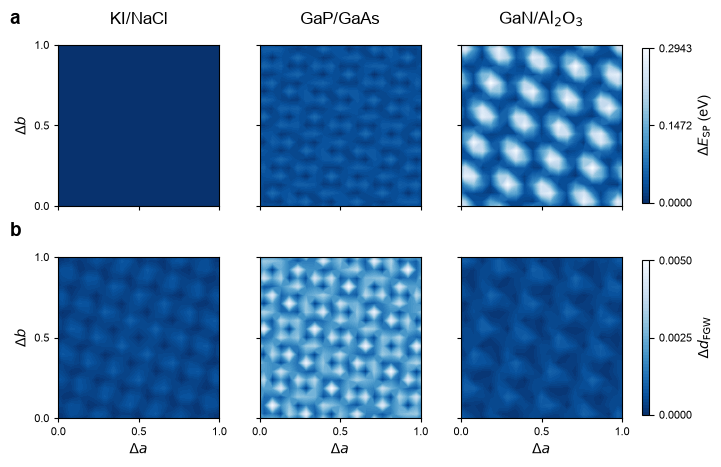

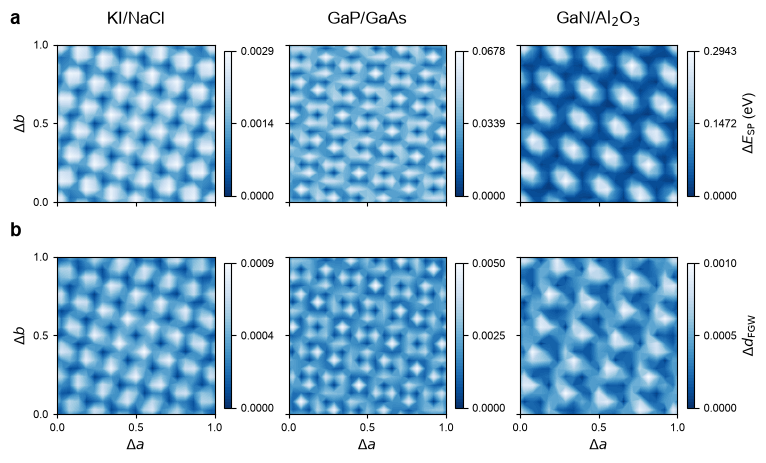

In [8]:
def plot_landscapes(scale_mode, output_path):
    """
    Parameters
    ----------
    scale_mode: {"row", "panel"}
    * "row": All three panels in the same row use a common color scale.
    * "panel": Each panel uses its own color scale.
    output_path: str, Name of the output PDF file
    """
    fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))
    plt.subplots_adjust(**fig_layout)
    energy_contours = []
    fgw_contours = []
    for i, (title, data) in enumerate(zip(titles, data_store)):
        x, y, z_energy, z_fgw_d = data
        # Periodically extend the centered registry grid on both sides.
        x = np.r_[x[-1]-1.0, x, x[0]+1.0]
        y = np.r_[y[-1]-1.0, y, y[0]+1.0]
        z_energy = np.pad(z_energy, pad_width=1, mode="wrap")
        z_fgw_d = np.pad(z_fgw_d, pad_width=1, mode="wrap")
        if scale_mode == "row":
            energy_vmin = energy_min
            energy_vmax = energy_max
            fgw_d_vmin = fgw_d_min
            fgw_d_vmax = fgw_d_max
        elif scale_mode == "panel":
            energy_vmin = z_energy.min()
            energy_vmax = z_energy.max()
            fgw_d_vmin = z_fgw_d.min()
            fgw_d_vmax = z_fgw_d.max()
        else:
            raise ValueError("Scale mode should be row or panel.")
        # Row 1: MACE single-point energy landscapes
        c_energy = axes[0, i].contourf(
            x, y, z_energy,
            levels=np.linspace(energy_vmin, energy_vmax, levels),
            cmap=cmap,
            vmin=energy_vmin, vmax=energy_vmax,
        )
        energy_contours.append(c_energy)
        # Row 2: FGW distance landscapes
        c_fgw = axes[1, i].contourf(
            x, y, z_fgw_d,
            levels=np.linspace(fgw_d_vmin, fgw_d_vmax, levels),
            cmap=cmap,
            vmin=fgw_d_vmin, vmax=fgw_d_vmax,
        )
        fgw_contours.append(c_fgw)
        # Panel formatting
        for row in range(2):
            ax = axes[row, i]
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.0)
            ax.set_xticks([0, 0.5, 1.0])
            ax.set_yticks([0, 0.5, 1.0])
            ax.set_aspect("equal")
            ax.tick_params(direction="out", length=3, width=0.8)
            if i != 0:
                ax.tick_params(labelleft=False)
        axes[0, i].set_title(title, pad=15)
        axes[0, i].tick_params(labelbottom=False)
        axes[1, i].set_xlabel(r"$\Delta a$")
        if i == 0:
            axes[0, i].set_ylabel(r"$\Delta b$")
            axes[1, i].set_ylabel(r"$\Delta b$")
    # Add row labels
    axes[0, 0].text(
        -0.3, 1.13,
        "a",
        transform=axes[0, 0].transAxes,
        fontsize=panel_label_size,
        fontweight="bold",
    )
    axes[1, 0].text(
        -0.3, 1.13,
        "b",
        transform=axes[1, 0].transAxes,
        fontsize=panel_label_size,
        fontweight="bold",
    )
    if scale_mode == "row":
        cbar_energy = fig.colorbar(
            energy_contours[0],
            ax=axes[0, :],
            orientation="vertical",
            fraction=0.1,
            pad=0.03,
            shrink=0.8,
        )
        cbar_energy.set_label(r"$\Delta E_{\mathrm{SP}}$ (eV)")
        cbar_energy.set_ticks([energy_min, (energy_min+energy_max)/2, energy_max])
        cbar_energy.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
        cbar_fgw = fig.colorbar(
            fgw_contours[0],
            ax=axes[1, :],
            orientation="vertical",
            fraction=0.1,
            pad=0.03,
            shrink=0.8,
        )
        cbar_fgw.set_label(r"$\Delta d_{\mathrm{FGW}}$")
        cbar_fgw.set_ticks([fgw_d_min, (fgw_d_min+fgw_d_max)/2, fgw_d_max])
        cbar_fgw.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    else:
        for i, data in enumerate(data_store):
            _, _, z_energy, z_fgw_d = data
            panel_energy_min = z_energy.min()
            panel_energy_max = z_energy.max()
            panel_fgw_min = z_fgw_d.min()
            panel_fgw_max = z_fgw_d.max()
            cbar_energy = fig.colorbar(
                energy_contours[i],
                ax=axes[0, i],
                orientation="vertical",
                fraction=0.1,
                pad=0.05,
                shrink=0.75,
            )
            cbar_energy.set_ticks([panel_energy_min, (panel_energy_min+panel_energy_max)/2, panel_energy_max])
            cbar_energy.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
            cbar_fgw = fig.colorbar(
                fgw_contours[i],
                ax=axes[1, i],
                orientation="vertical",
                fraction=0.1,
                pad=0.05,
                shrink=0.75,
            )
            cbar_fgw.set_ticks([panel_fgw_min, (panel_fgw_min+panel_fgw_max)/2, panel_fgw_max])
            cbar_fgw.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
            if i == 2:
                cbar_energy.set_label(r"$\Delta E_{\mathrm{SP}}$ (eV)")
                cbar_fgw.set_label(r"$\Delta d_{\mathrm{FGW}}$")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_landscapes(scale_mode="row", output_path="fgw_mace_sp_landscapes_row_scales.pdf")
plot_landscapes(scale_mode="panel", output_path="fgw_mace_sp_landscapes_panel_scales.pdf")
